# Machine Learning 

## An overview

Machine Learning involves developing algorithms which automatically make inferences from data. In this course we will mostly focus on __supervised learning__, but will also briefy discuss __unsupervised learning__ when we do clustering and topic modeling. Two of the most common supervised learning tasks are __classification__ and __regression__.

### Classification


<figure class="image" style="width:50%">
  <img src="cat_dog.jpg" alt="Cats vs Dogs">
  <figcaption><i>Given an image, can you tell if it is a cat or a dog.</i></figcaption>
</figure>

<figure class="image" style="width:50%">
  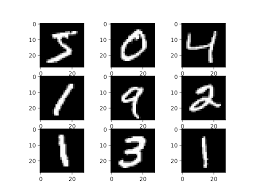
  <figcaption><i>Can you recognize handwritten digits?</i></figcaption>
</figure>


In this task, you would be given bunch of images $X_1,\ldots,X_N$ with 'labels' $y_1,\ldots,y_N$. This is called __training data__. The question is this. If you were given some new image, can you accurately tell whether it is a cat or a dog (or what number it is)?

Research into automatically understanding images, as well as audio and video, has drastically accelerated in the past decade thanks to sophisticated architectures like convolutional neural networks (CNNs) and transformer models. These advances have led to the development of technologies such as AI assistants like ChatGPT, as well as significant progress in autonomous vehicles. We'll discuss image classification in a later lecture. 

For now, we will focus on the Titanic set which is based on the 1997 film Titanic starring Leonardo Dicaprio and Kate Winslet. 

<figure class="image" style="width:50%">
  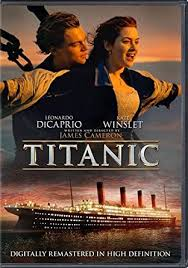
  <figcaption><i>Can you predict, from data which people survived?</i></figcaption>
</figure>


### Regression

Regression is similar to classification, but rather than giving each data point a category such as cat/dog, or survived / didn't survive, you try to give every data point a number.

For example, you could try to predict how happy people are in a given country (on average) from other data. The good old fashioned "line of best" fit is also an important example of regression.

<figure class="image" style="width:50%">
  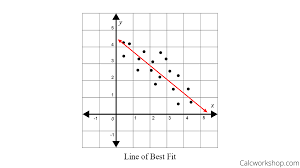
  <figcaption><i>The data doesn't match the model exactly, but hopefully we are close.</i></figcaption>
</figure>

### Common mathematical framework for both regression and classification

You will have __predictor variables__ usually called __x__ or __X__. These could be the input images for cats/dogs, or could be the age/wealth of a passenger on the titanic. For the happiness example, it could be things like the average income of people in the country.

You will also have a __target variable y__ . This is the thing you are trying to predict. For regression tasks, this is usual a real number. For classification tasks it is commonly "Type 0" or "Type 1".

We assume that there is a __model__ (or function) $f$ such that $y\approx f(X)$. We will assume that $f$ is required to belong to a prespecified class of functions $\mathcal{M}$ called the model class (or hypothesis set). If the model class is "all linear functions" then we can get __linear regression__. Similarly, if you took the model class to be all polynomials of degree less than 10, you could get __polynomial regression__. Another common choice is applications related to e.g., audio, is to use a bunch of sines and cosines (Fourier analysis). 

For classification classes, a possible model class would be the set of all binary decision trees.

<figure class="image" style="width:50%">
  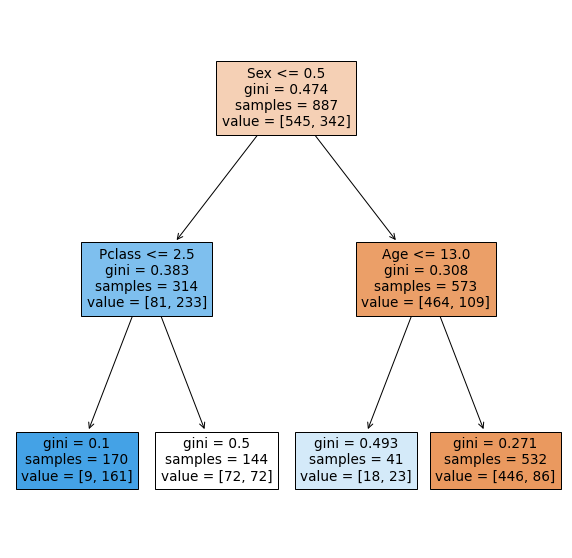
  <figcaption><i>Decision tree for who survived the Titanic</i></figcaption>
</figure>

 __Loss function__ - How do we decide the best model from our model class?
 
 We assume that we have a bunch of data points $(X_1,y_1),\ldots,(X_N,y_N)$ and try to compute
 
 \begin{equation*}
 \min_{f\in\mathcal{M}} \frac{1}{N}\sum_{i=1}^N \mathcal{L}(f(X_i),y_i)
 \end{equation*}

__Common example:__ Least squares
\begin{equation*}
\sum_i\mathcal{L}(f(X_i),y_i) = \sum_i |f(X_i)-y_i|^2
\end{equation*}

<figure class="image" style="width:50%">
  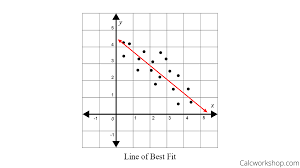
  <figcaption><i>Find the best line that is closest to the dots.</i></figcaption>
</figure>

That's it for our conceptual overview of machine learning.

In summary, the supervised machine learning task has four major components: 

1. The <font color="green"><i>predictor variables</i> $X$</font>. 
2. The <font color="gold"><i>target variable</i> $Y$</font>, which we aim to predict using <font color="green">$X$</font>. 
3. The <font color="blue"> <i>model</i> $f$ </font>. We treat $\color{blue}{f}(\color{green}{X})$ as our estimate of $\color{gold}{Y}$. 
1. <font color="red"><i>The loss function</i> $\mathcal{L}$</font>. The quantity $\color{red}{\mathcal{L}}(\color{blue}{f}(\color{green}{X}), \color{gold}{Y})$ is a measure of how well the model $\color{blue}{f}$ "fits" the data $(\color{green}{X}, \color{gold}{Y})$. 

Next, we will explore each of these components in an interpretable setting -- linear regression. This will help us understand what's really going on when we start using more complicated models from Python packages. 

## Linear Regression

In linear regression, we use a *linear* model for the data. In the 1-dimensional case, this means that our model $\color{blue}{f}$ has the form 

$$\color{blue}{f}(\color{green}{x}) = a\color{green}{x}+b \approx \color{gold}{y}\;.$$

There are two parameters: the slope $a$ and the intercept $b$. By changing the slope and intercept, we get different models. We say that $\color{blue}{f}$ belongs to a *family* of models $\color{blue}{\mathcal{M}}$, with each model corresponding to a different choice of $a$ and $b$. Our learning task now is to find good choices for $a$ and $b$, given some data. 

### Predictor and Target Data

Let's now generate some synthetic data to use as our example.

In [1]:
import numpy as np 
from matplotlib import pyplot as plt

We will use a synthetic, randomly generated data set The following line seed our random number generator so we get the same thing every time

In [2]:
np.random.seed(1234)

Our data will be 100 points from the line y=x+1 plus a random error which we model as a normal random variable with standard deviation .2

In [5]:
a = 1
b = 1 
n_points = 100
X = np.random.rand(100)
Y = a*X + b + 0.2*np.random.randn(n_points)

print(X)
print(Y)

[0.33230155 0.97881821 0.2032152  0.66702606 0.57478427 0.05197529
 0.5428381  0.20794911 0.09109018 0.86985571 0.02736978 0.96862452
 0.32749989 0.41027796 0.13554422 0.12706631 0.41398398 0.61744374
 0.1322669  0.97448122 0.1806351  0.76034991 0.48216182 0.76807887
 0.30289844 0.01517509 0.46336869 0.70333708 0.06604089 0.66901142
 0.34547906 0.59172147 0.22905346 0.26756836 0.93282699 0.82614506
 0.14544319 0.64700361 0.88395117 0.74136053 0.5157108  0.13525184
 0.03988365 0.83432183 0.11705787 0.52310231 0.87305847 0.03870784
 0.69239079 0.47626848 0.16926449 0.06317189 0.03222409 0.24243086
 0.11270682 0.40499002 0.04207297 0.92656545 0.93526291 0.8104269
 0.18834308 0.58731822 0.90351056 0.96734226 0.06753921 0.31758607
 0.69686297 0.64026538 0.63262331 0.82875065 0.71311043 0.33548023
 0.16769468 0.76468982 0.35931506 0.08800478 0.7295676  0.88104993
 0.04126388 0.17486776 0.42009741 0.34060658 0.04476892 0.11289131
 0.43804149 0.0710732  0.81624511 0.86611565 0.13111984 0.19321

Let's take a look at our data

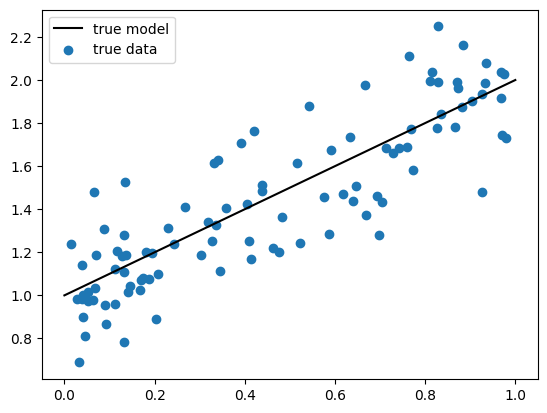

In [6]:
#plot points and true function
fig, ax = plt.subplots(1)

ax.plot([0,1],[1,2], color = 'black', label='true model')       # this is plotting the line
ax.scatter(X,Y,label = 'true data')                             # plotting our points
ax.legend()

In practice, we don't actually know the true function. So our situtaion looks a bit more like this

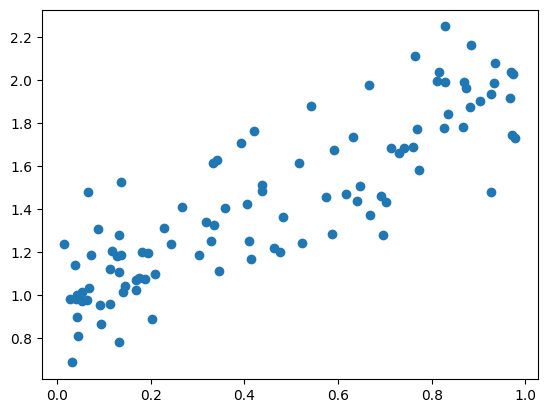

In [7]:
fig, ax = plt.subplots(1)
ax.scatter(X,Y,label = 'true data')

If we stare at the data, we can see that it kind of looks like we might be able to fit it with a line of the form 

Y=a*X+b

Let's use a function to formalize this model. When thinking about this conceptually we can regard X as the input and regard a and b as learnable parameters, but when we write the code they are all just input parameters

In [8]:
#LM stands for linear model
def LM(X,a,b):
    return a*X + b

def linear_model(X,a,b):                            # X is the data, a is the slope and b the intercept
    return a*X + b  

Let's see how our model works against some data

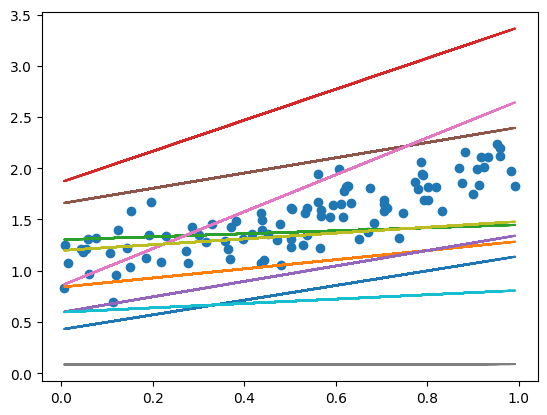

In [ ]:
for i in range(10):
    a = 2*np.random.rand()                  # gonna give a random FLOAT for guess of slope
    b = 2*np.random.rand()                  # gonna give a random FLOAT for guess of intercept 
    ax.plot(X, LM(X,a,b))                   # using ax.plot plots a LINE !


fig

Some of these <font color = "blue"> models </font> look better than others! How do we pick, systematically? Well, that's where the <font color="red"> loss function $\mathcal{L}$ </font> comes in. The most common choice in linear regression is the <font color="red"> <i> mean-square error</i></font>, which is defined as follows: 

$$\color{red}{\mathcal{L}}(\color{blue}{f}(\color{green}{X}),\color{gold}{Y}) = \frac{1}{n}\left[ (\color{gold}{y}_1 - \color{blue}{f}(\color{green}{x}_1))^2 + (\color{gold}{y}_2 - \color{blue}{f}(\color{green}{x}_2))^2 + \cdots + (\color{gold}{y}_n - \color{blue}{f}(\color{green}{x}_n))^2\right]$$

A term like $(\color{gold}{y}_i - \color{blue}{f}(\color{green}{x}_i))^2$ is large when $\color{blue}{f}(\color{green}{x}_i)$ is very different from $\color{gold}{y}_i$ -- that is, when our prediction is off! So, if a <font color="blue">model</font> has a low <font color="red">mean-square error </font>$\color{red}{\mathcal{L}}$, then this indicates that the <font color="blue">model</font> "fits the data" well. 

Let's implement the <font color="red">mean-square error</font> for linear regression.  The error depends on the parameters $a$ and $b$. `numpy` array operations make this very easy.

In [9]:
def linear_MSE(X,Y,a,b):
    Error = Y - LM(X,a,b)
    return (Error**2).mean()



# we want to make mean squared error 
def linear_mean_squared_error(Y,X,a,b):         # y is our value, x is our data, a is slope, b is the intercept
    my_error = Y-LM(X,a,b)
    return (my_error**2).mean()

Now let's go back to our plot of the data and show how all those candidate models perform when evaluated using the <font color="red">MSE loss function</font>. We're going to 

-  Make all of our lines black
-  tune our visualization so that the <font color="blue">models</font> with lower <font color="red">MSE</font> are drawn thicker:

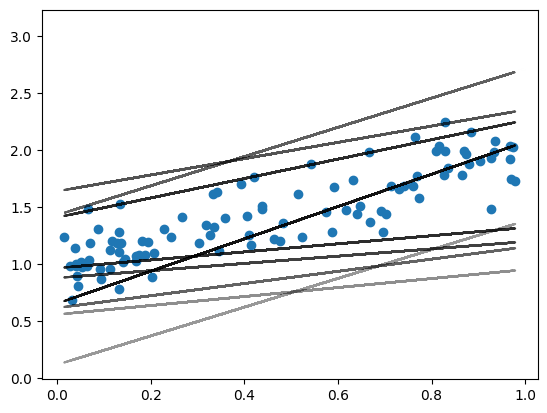

In [ ]:
fig, ax = plt.subplots(1)           # new plot fig, ax = plt.subplots(1,1)
ax.scatter(X,Y)                     # adding the data from before 

for i in range(10):
    a = 2*np.random.rand()
    b = 2*np.random.rand()

    ax.plot(X, LM(X,a,b), color = 'black',alpha =max(0 ,1-linear_MSE(X,Y,a,b)))


Hey, this looks pretty good! The <font color="blue">models</font> that have lower <font color="red">MSE</font> (darker lines) "look close" to the data. 

Let's see if we can estimate $a$ and $b$. One way to do this is by simply generating a lot of random possibilities and picking the best one. Let's plot a number of models and highlight the best one in a different color.

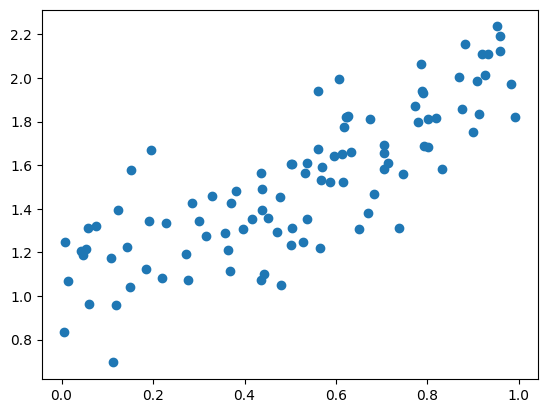

In [12]:
#naive selection 
fig, ax = plt.subplots(1)
ax.scatter(X,Y)

Now, lets check on the best_a and best_b __learned__ from the data. (Recall the true values are a=b=1)

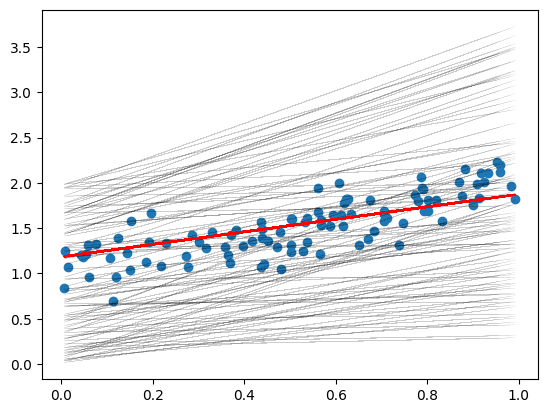

In [14]:
# make 100 lines plot, them , if error < best error perform update

#naive selection 
fig, ax = plt.subplots(1)
ax.scatter(X,Y)


best_error = np.inf
for i in range(100):
    a = 2*np.random.rand()
    b = 2*np.random.rand()
    preds = LM(X,a,b)
    error = linear_MSE(X,Y,a,b)

    ax.plot(X, preds, color = 'black',alpha = 0.2, linewidth =0.1)

    if error < best_error:
        best_error = error
        best_a = a
        best_b = b

best_preds = LM(X,best_a,best_b)
ax.plot(X,best_preds, color = 'red')

# **end of 7 friday**

# Recap

In this lecture, we did linear regression "by hand." We generated some synthetic <font color="green">predictor data</font> and <font color="gold">target data</font>. We then modeled the data using a family of one-dimensional <font color="blue"> linear models</font>, and selected from among the many possibilities using the <font color="red">mean square error loss function</font>. Choosing the <font color="blue">model </font> that minimized the <font color="red">loss function</font> led to a good "fit" to the data. 

This pattern applies to essentially all problems in (supervised) machine learning: 

1. Collect some <font color="green">predictor data</font> and <font color="gold">target data</font>. 
2. Define a family of <font color="blue">models</font> and <font color="red">loss function</font>.  
3. Find the element of the <font color="blue">model family</font> that minimizes the <font color="red">loss function</font>. 

There are a few outstanding issues that we haven't covered here. The biggest one is that "fitting the data" is not actually what we usually care about -- we care about *predicting* unseen data. It turns out that fitting the data too closely can actually be counter productive in this case. This is the problem of *overfitting*, which we'll consider in a future lecture. 

## Bonus material
In the above example, we just picked a bunch of different a's and b's completely at random. We did this, because it is simple, but it is not what you would do in practice. Without getting to much into the weeds, here is what you would do in practice.

### Conceptual - Gradient Descent

1) Start with a initial guesses a_0, b_0.

2) Based on how your model works with a_0 and b_0, come up with another guess a_1 and b_1 which are better than the initial guess

3) Repeat this processs so that a_2,b_2 are better than a_1,b_1, and a_3,b_3 are even better than a_2,b_2,...

4) Don't stop until your model is sufficiently good

If you have taken calculus (not required) this might remind you of Newton's method for solving equations. Indeed, the rule for getting a "better guess" relies on taking the derivative of the loss function and doing some calculus. The name for this procedure is Gradient Descent.



### Practical - Scipy.optimize

In [15]:
from scipy.optimize import minimize
res = minimize(lambda z: linear_MSE(X,Y,z[0],z[1]), np.array([0,0]))
print(res)
optimal_a, optimal_b = res.x
print(optimal_a, optimal_b)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.037090334781149925
        x: [ 9.765e-01  1.015e+00]
      nit: 6
      jac: [ 7.553e-07  1.350e-06]
 hess_inv: [[ 6.524e+00 -3.392e+00]
            [-3.392e+00  2.245e+00]]
     nfev: 21
     njev: 7
0.976529904157296 1.0152617349077613


This is exactly what is going on "under the hood" of most prepackaged machine learning algorithms, which we'll begin to see in the next few lectures. 

Having obtained the optimal parameters, we are now able to make predictions on unseen data. For example: 

In [16]:
# model prediction when X = 0.7
optimal_preds = LM(X,optimal_a, optimal_b)
ax.plot(X, optimal_preds, color='blue')

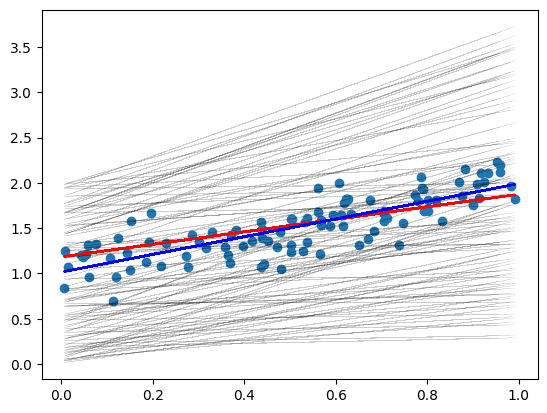

In [17]:
fig

In [18]:
# model prediction when X = 0.7
LM(np.array([0.7]),optimal_a, optimal_b)

array([1.69883267])